# XGBoost Binary Classification

This notebook implements a complete machine learning pipeline for binary classification of coronary artery stenosis using XGBoost.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data, create binary target
3. **Dropping dependent Features**: Remove derived variables
4. **Preprocessing**: Clean data, handle missing values, and prepare features
5. **Build Pipeline**: Train XGBoost classifier with SMOTE and feature selection
6. **Evaluation**: Comprehensive evaluation metrics
7. **Overfitting Check**: Compare training vs. test performance
8. **Visualization**: ROC and Precision-Recall curves
9. **Feature Importance**: Identify most important features
10. **Gridsearch** (Optional): Hyperparameter optimization
11. **Feature Selection Optimization** (Optional): Find optimal number of features

## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **xgboost**: Gradient boosting classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization
- **scipy.stats**: Statistical distributions for randomized search

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import uniform, randint

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
    precision_recall_curve,
    f1_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt



## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Removes features with more than 62.5% missing values
- Removes class 1 (non-significant stenosis) to create binary classification
- Automatically converts object columns that look numeric to appropriate data types
- Displays cleaned dataset shape

In [2]:
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)
display(data.head(30))

threshold = 0.625
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(
    f"Converted {len(numeric_like_cols)} mostly-numeric columns: {numeric_like_cols}"
)
print(f"Cleaned dataset shape: {data.shape}")



/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_80837/4217982362.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,"56,9691991786448",0,112,",982456140350877","32,8731097961867",0,130.0,80.0,50.0,...,"9,44","4,38","3,99","14,1","25,8","7,8","3,99","3,99","3,99","3,99"
1,2,"69,4976043805613",0,104,"1,04","30,1102788964583",0,160.0,70.0,90.0,...,"19,8","8,97","7,75","21,9","41,3","20,1","7,35",NaN,"7,45","8,11"
2,2,"72,0492813141684",0,129,",941605839416058","44,7348800491207",0,140.0,90.0,50.0,...,"13,9","4,75","3,99","20,3","52,4","18,6","3,99","3,99","3,99","3,99"
3,2,"70,8145106091718",0,99,",876106194690266","26,2595847484332",0,130.0,90.0,40.0,...,20,"8,73","7,85","25,3","50,7",17,0,NaN,"7,63","9,02"
4,2,"62,1601642710472",1,125,NaN,"42,4366343891054",1,180.0,100.0,80.0,...,"16,9","9,14","8,3","29,5",43,"17,9","8,13",0,"8,4","8,51"
5,2,"73,82340862423",1,97,",989795918367347","26,4462809917355",0,157.0,85.0,72.0,...,"13,1",8,"7,4","15,1","26,4","15,2","7,4","3,89","7,53","8,15"
6,2,"58,4284736481862",1,92,",978723404255319","25,78125",1,130.0,85.0,45.0,...,"16,5","8,61",0,"21,5",48,"20,4",0,NaN,"7,71","9,31"
7,2,"54,5954825462012",0,NaN,NaN,"32,4661454995942",1,140.0,80.0,60.0,...,"18,7","8,84","8,54","28,2","42,7","15,9","8,28",0,"8,44","8,83"
8,2,"76,1724845995893",0,92,",884615384615385","27,2392244832559",0,150.0,110.0,40.0,...,"18,8","8,84","7,71","18,6","40,4","20,8","7,03",0,"7,77","8,3"
9,2,"46,7953456536619",1,81,",931034482758621","20,8209399167162",1,110.0,70.0,40.0,...,"9,25","4,13","3,99","15,7","39,9","14,5","3,99","3,99","3,99","3,99"


Converted 6 mostly-numeric columns: ['Alter_0', 'BMI_0', 'hba1c0', 'TyG_Index_neu', 'crp0', 'Kreat0']
Cleaned dataset shape: (1678, 94)


## 3. Dropping dependent Features

This cell removes dependent variables that are directly derived from other features. These features contain redundant information and can cause multicollinearity issues.

In [3]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)
print(list(data.columns))

['OUTCOME_3Kat_KHK', 'Alter_0', 'geschlecht', 'waist_0', 'WHR_0', 'BMI_0', 'currsmo0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'diabetes_ADA_final_0', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'Kalium0', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'Cer_d18_16', 'Cer_d18_18', 'Cer_d

## 4. Preprocessing

This cell performs comprehensive data preprocessing:

**Feature Type Identification:**
- Identifies categorical and numerical features
- Automatically converts object columns that look numeric
- Handles manual categorical feature definitions

**Data Cleaning:**
- Removes highly correlated features (correlation > 0.95) to reduce redundancy
- Creates binary target: 0 = No Stenosis, 1 = Significant Stenosis

**Train/Test Split:**
- Splits data into 80% training and 20% test set
- Uses stratified split to maintain class distribution

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: Median imputation

In [4]:
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
    ]
resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)
if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )


numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): sample -> {numerical_features[:5]}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerische Features: {len(numerical_features)}")
print(f"After cleaning - Kategoriale Features: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_pre = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)



Forced 48 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (79): sample -> ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0']
Removing 1 highly correlated features
After cleaning - Numerische Features: 78
After cleaning - Kategoriale Features: 7


## 5. Build Pipeline

This cell builds and trains the XGBoost model with the complete pipeline:

**Process:**
1. Fits preprocessor on training data and transforms both sets
2. Performs feature selection (SelectKBest with mutual information, k=50)
3. Calculates `scale_pos_weight` to handle class imbalance in binary classification
4. Builds pipeline with SMOTE (oversampling) and XGBoost classifier
5. Performs 5-fold cross-validation to assess model performance
6. Trains final model on full training set
7. Makes predictions on test set

**Hyperparameters:**
- Optimized for high recall of Significant Stenosis (class 1)
- Regularization parameters to prevent overfitting
- `scale_pos_weight` calculated based on class distribution

In [5]:
np.random.seed(42)

temp_preprocessor = preprocessor.fit(X_train, y_train)
X_train_transformed = temp_preprocessor.transform(X_train)
X_test_transformed = temp_preprocessor.transform(X_test)

selector = SelectKBest(mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution - Class 0 (No Stenosis): {class_counts[0]}, Class 1 (Significant Stenosis): {class_counts[1]}")

base_ratio = class_counts[1] / class_counts[0]

scale_pos_weight_multiplier = 0.4 
scale_pos_weight = base_ratio * scale_pos_weight_multiplier

print(f"Base ratio (class 1 / class 0): {base_ratio:.2f}")
print(f"Multiplier (accounts for SMOTE): {scale_pos_weight_multiplier}")
print(f"Final scale_pos_weight: {scale_pos_weight:.2f} (favors class 1 - Significant Stenosis)")
print(f"  → XGBoost will weight class 1 samples {scale_pos_weight:.2f}x more than class 0")
print(f"  → This should increase recall for Significant Stenosis (class 1)")

pipeline = Pipeline(
    [
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=200,
            learning_rate=0.01, 
            max_depth=3, 
            min_child_weight=5, 
            subsample=0.8, 
            colsample_bytree=0.7, 
            reg_lambda=3.0, 
            reg_alpha=1.5, 
            scale_pos_weight=scale_pos_weight, 
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )),
    ]
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_selected, y_train, cv=cv_strategy, scoring='balanced_accuracy')

pipeline.fit(X_train_selected, y_train)

y_pred = pipeline.predict(X_test_selected)
y_proba = pipeline.predict_proba(X_test_selected)





Selected 50 features out of 96
Class distribution - Class 0 (No Stenosis): 306, Class 1 (Significant Stenosis): 1036
Base ratio (class 1 / class 0): 3.39
Multiplier (accounts for SMOTE): 0.4
Final scale_pos_weight: 1.35 (favors class 1 - Significant Stenosis)
  → XGBoost will weight class 1 samples 1.35x more than class 0
  → This should increase recall for Significant Stenosis (class 1)


## 6. Evaluation

This cell provides a comprehensive evaluation of the model's performance on the test set.

**Metrics Reported:**
- **Recall for Class 1** (Significant Stenosis): Most important metric for clinical application
- **Balanced Accuracy**: Average recall across both classes (better for imbalanced data)
- **Classification Report**: Per-class precision, recall, F1-score, and support
- **Cross-Validation Score**: Mean balanced accuracy from 5-fold CV

In [6]:
report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"])

balanced_acc = balanced_accuracy_score(y_test, y_pred)

recall_class1 = recall_score(y_test, y_pred, pos_label=1)

print("=" * 80)
print("MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\nTest Recall (Significant Stenosis): {recall_class1:.4f}")
print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f}")
print("\nClassification Report:")
print(report)



MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)

Test Recall (Significant Stenosis): 0.8746
Test Balanced Accuracy: 0.6829
Mean Cross-Validation Balanced Accuracy: 0.6937

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.44      0.49      0.47        57
Significant Stenosis       0.89      0.87      0.88       279

            accuracy                           0.81       336
           macro avg       0.67      0.68      0.68       336
        weighted avg       0.82      0.81      0.81       336



In [7]:
y_pred_train = pipeline.predict(X_train_selected)
y_pred_test = y_pred

train_recall_class1 = recall_score(y_train, y_pred_train, pos_label=1)
test_recall_class1 = recall_score(y_test, y_pred_test, pos_label=1)

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\nRecall (Significant Stenosis):")
print(f"  Training: {train_recall_class1:.4f}")
print(f"  Test:     {test_recall_class1:.4f}")
print(f"  Gap:      {train_recall_class1 - test_recall_class1:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")
    print(f"  Recall gap: {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")




OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)

Recall (Significant Stenosis):
  Training: 0.8842
  Test:     0.8746
  Gap:      0.0096

Balanced Accuracy:
  Training: 0.7313
  Test:     0.6829
  Gap:      0.0484

Regular Accuracy:
  Training: 0.8145
  Test:     0.8095
  Gap:      0.0049

Model shows good generalization (small gap between train/test)
  Recall gap: 0.0096 (good)
  Balanced accuracy gap: 0.0484 (good)


## 8. Visualization

This cell visualizes model performance using:
- **Confusion Matrix**: Shows classification results for both classes
- **ROC Curve**: Trade-off between True Positive Rate and False Positive Rate with AUC score
- **Precision-Recall Curve**: Trade-off between precision and recall, more informative for imbalanced datasets

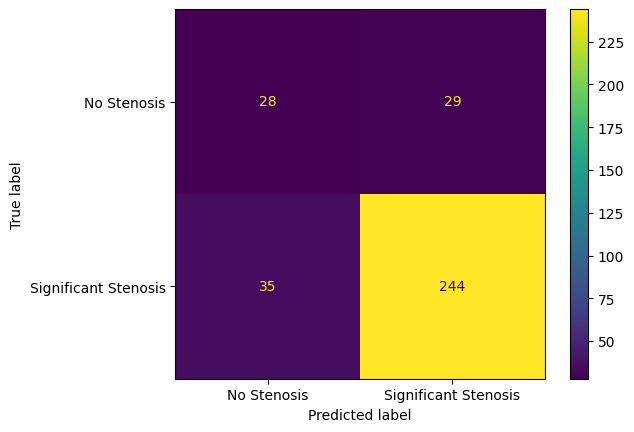

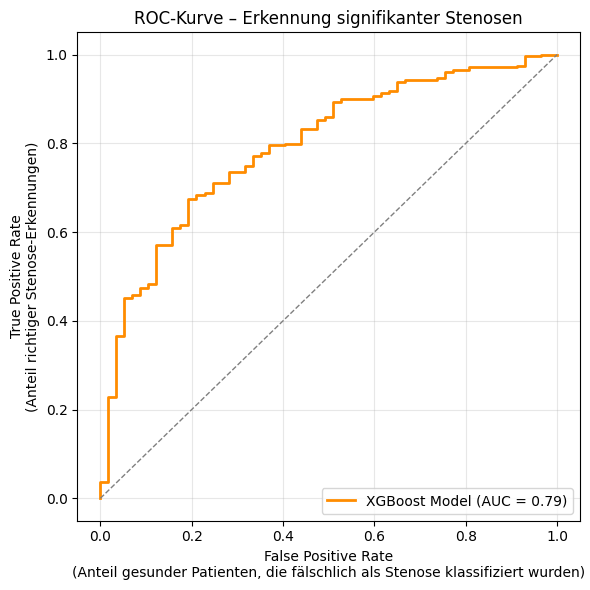

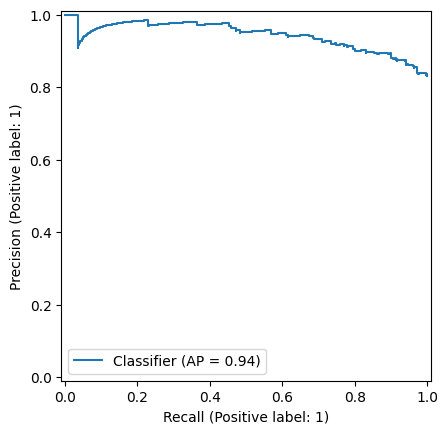

In [23]:
clf = pipeline.named_steps["classifier"]
y_pred = clf.predict(X_test_selected)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

y_prob = clf.predict_proba(X_test_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

plt.xlabel("False Positive Rate\n(Anteil gesunder Patienten, die fälschlich als Stenose klassifiziert wurden)")
plt.ylabel("True Positive Rate\n(Anteil richtiger Stenose-Erkennungen)")
plt.title("ROC-Kurve – Erkennung signifikanter Stenosen")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, clf.predict_proba(X_test_selected)[:, 1])



## 9. Feature Importance

This cell identifies and visualizes the most important features used by the XGBoost model.

**Process:**
- Extracts feature names from the preprocessing pipeline
- Maps selected features (after feature selection) to their original names
- Uses XGBoost's built-in feature importance (based on F-score/weight)
- Displays the top 10 most important features

**Interpretation:**
- Features with higher F-scores contribute more to the model's predictions
- This helps understand which patient characteristics are most predictive of significant stenosis
- Useful for clinical interpretation and feature engineering insights

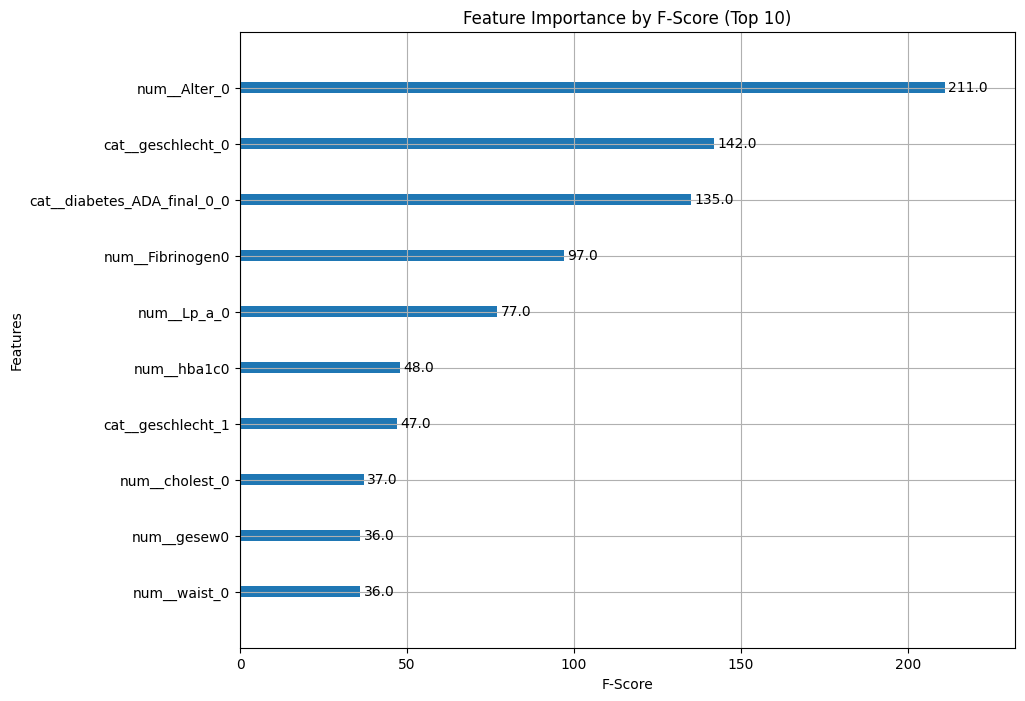

In [24]:
all_feature_names = temp_preprocessor.get_feature_names_out()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [all_feature_names[i] for i in selected_indices]

xgb_model = pipeline.named_steps['classifier']

booster = xgb_model.get_booster()

booster.feature_names = selected_feature_names

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()


--- Worst 10 Features by F-Score Importance ---
                                              Feature  Importance
1   cat__Osteoporos_inkl_Osteopenie_T_Wert_abhängi...         1.0
33                                num__GOT_GPT_Ratio0         1.0
32                                          num__got0         1.0
31                               num__Cystatin_gesamt         1.0
45                                          num__CERT         2.0
43                     num__Cer_d18_16_I_Cer_d18_24_0         2.0
28                              num__Kreatinin_Harn_0         2.0
24                               num__NEUT_ABS_gesamt         3.0
44                                         num__PC_32         4.0
38                                          num__ptt0         4.0


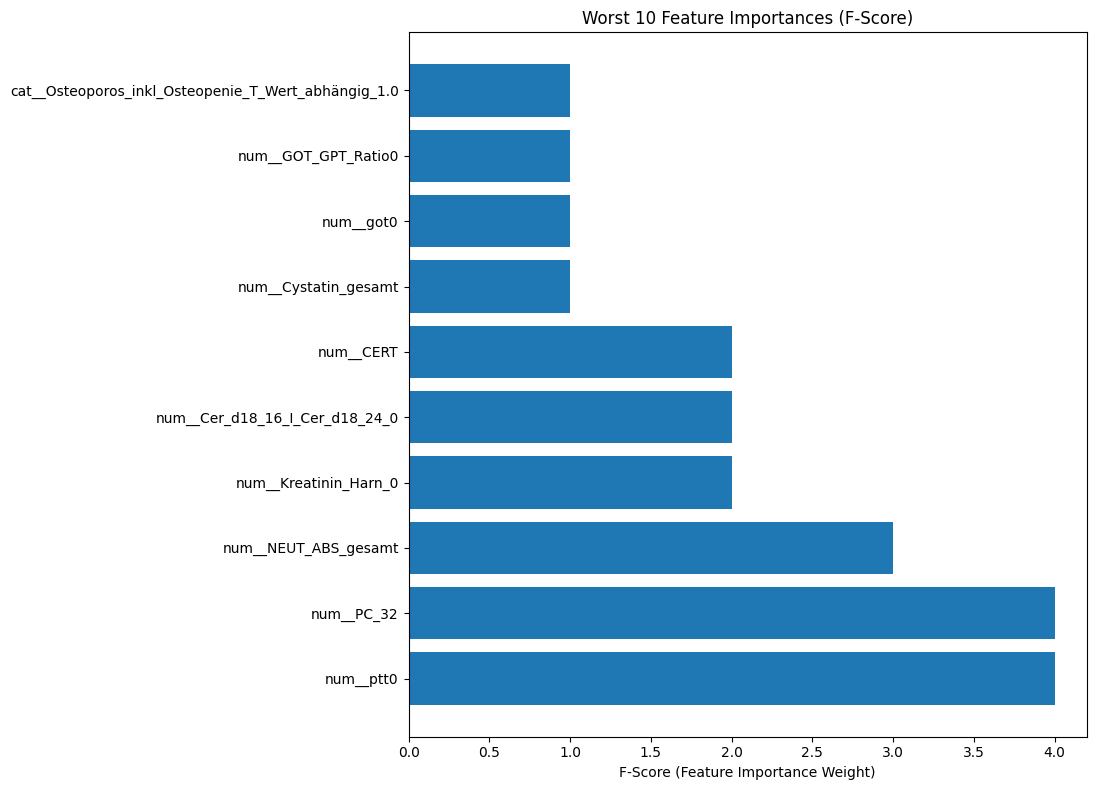

In [25]:
fig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

ax_top.set_visible(False)

importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()


In [26]:
feature_treatment = pd.DataFrame({
    'feature': X.columns,
    'pandas_dtype': X.dtypes.astype(str),
    'treated_as': [
        'categorical' if col in categorical_features else (
            'numerical' if col in numerical_features else 'other'
        )
        for col in X.columns
    ]
})
display(feature_treatment.sort_values(['treated_as', 'feature']).reset_index(drop=True))
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")



,feature,pandas_dtype,treated_as
0,ANY_OPE,object,categorical
1,ANY_OPO,object,categorical
2,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,object,categorical
3,Osteoporose_T_Wert_abhängig,object,categorical
4,currsmo0,object,categorical
...,...,...,...
80,quick0,float64,numerical
81,remnantCholesterol0,float64,numerical
82,triglyc_0,float64,numerical
83,tsh0,float64,numerical


Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (78): ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'Kalium0', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'Cer_d18_16',

## 10. Gridsearch (Optional)

This cell performs hyperparameter optimization using RandomizedSearchCV with a custom scorer that prioritizes recall for Significant Stenosis (class 1).

**Process:**
- Uses a custom scorer combining 65% recall for class 1 and 35% balanced accuracy
- Tests 50 random parameter combinations from defined distributions
- Uses 5-fold stratified cross-validation
- Saves the best model and evaluates its performance

**Note:** This cell can take a long time to run. It's optional and can be skipped if you're satisfied with the default model performance.

In [ ]:
def combined_recall_balanced_scorer(y_true, y_pred):
    recall_class1 = recall_score(y_true, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return 0.65 * recall_class1 + 0.35 * bal_acc

custom_scorer = make_scorer(combined_recall_balanced_scorer)

param_distributions = {
    'classifier__n_estimators': randint(150, 400),
    'classifier__max_depth': randint(2, 5),
    'classifier__learning_rate': uniform(0.01, 0.04),
    'classifier__subsample': uniform(0.7, 0.2),
    'classifier__colsample_bytree': uniform(0.6, 0.2),
    'classifier__min_child_weight': randint(1, 8),
    'classifier__reg_lambda': uniform(1.0, 4.0),
    'classifier__reg_alpha': uniform(0.5, 2.0),
    'classifier__scale_pos_weight': uniform(0.5, 1.5),
}

pipeline_for_search = Pipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("classifier", XGBClassifier(
        tree_method="hist",
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )),
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline_for_search,
    param_distributions=param_distributions,
    n_iter=50,
    scoring=custom_scorer,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

print("Starting RandomizedSearchCV...")
print("Objective: Maximize Recall for Significant Stenosis (Class 1) + Balanced Accuracy")
print("Scoring: 65% Recall(Class 1) + 35% Balanced Accuracy")
print("This will try 50 random parameter combinations")
random_search.fit(X_train_selected, y_train)

print(f"\nBest combined score (CV): {random_search.best_score_:.4f}")
print('Best params:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

best_model = random_search.best_estimator_

y_pred_rs = best_model.predict(X_train_selected)
y_pred_rs_test = best_model.predict(X_test_selected)

train_recall_class1 = recall_score(y_train, y_pred_rs, pos_label=1)
test_recall_class1 = recall_score(y_test, y_pred_rs_test, pos_label=1)
train_bal_acc = balanced_accuracy_score(y_train, y_pred_rs)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_rs_test)

print(f"\n=== Best Model Performance ===")
print(f"Training - Recall (Class 1): {train_recall_class1:.4f}")
print(f"Training - Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Test - Recall (Class 1): {test_recall_class1:.4f}")
print(f"Test - Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Overfitting gap (Recall): {train_recall_class1 - test_recall_class1:.4f}")
print(f"Overfitting gap (BalAcc): {train_bal_acc - test_bal_acc:.4f}")

gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
if gap_recall > 0.15 or gap_bal > 0.15:
    print("\nWARNING: Large gap detected - model may be overfitting!")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("\nCAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("\nModel shows good generalization (small gap between train/test)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rs_test, target_names=["No Stenosis", "Significant Stenosis"]))



Starting RandomizedSearchCV...
Objective: Maximize Recall for Significant Stenosis (Class 1) + Balanced Accuracy
Scoring: 65% Recall(Class 1) + 35% Balanced Accuracy
This will try 50 random parameter combinations
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best combined score (CV): 0.8395
Best params:
  classifier__colsample_bytree: 0.6150692512012256
  classifier__learning_rate: 0.022227880771487275
  classifier__max_depth: 4
  classifier__min_child_weight: 1
  classifier__n_estimators: 216
  classifier__reg_alpha: 0.838985493372185
  classifier__reg_lambda: 3.2272050498334006
  classifier__scale_pos_weight: 1.9042321612411715
  classifier__subsample: 0.8392059593349945

=== Best Model Performance ===
Training - Recall (Class 1): 0.9730
Training - Balanced Accuracy: 0.7953
Test - Recall (Class 1): 0.9176
Test - Balanced Accuracy: 0.6430
Overfitting gap (Recall): 0.0554
Overfitting gap (BalAcc): 0.1523


Classification Report:
                      precision    recal

## 11. Feature Selection Optimization (Optional)

This cell tests different numbers of features (k values) to find the optimal feature count that balances model complexity and performance.

**Process:**
- Tests k values from 30 to 80 features
- For each k, performs quick 3-fold cross-validation with a simplified model
- Compares balanced accuracy scores across different k values
- Visualizes results to identify the optimal number of features
- Provides recommendation for best k value

**Note:** This is an optimization step that can help improve model performance by finding the right balance between feature count and model complexity.


Testing different feature selection k values...
k=30: CV Balanced Accuracy = 0.7120 (+/- 0.0328)
k=40: CV Balanced Accuracy = 0.7137 (+/- 0.0348)
k=50: CV Balanced Accuracy = 0.7031 (+/- 0.0350)
k=60: CV Balanced Accuracy = 0.7126 (+/- 0.0364)
k=70: CV Balanced Accuracy = 0.7041 (+/- 0.0426)
k=80: CV Balanced Accuracy = 0.7132 (+/- 0.0500)

Best k: 40 features (CV Balanced Accuracy: 0.7137)

Recommendation: Consider using k=40 instead of k=50 if performance is better


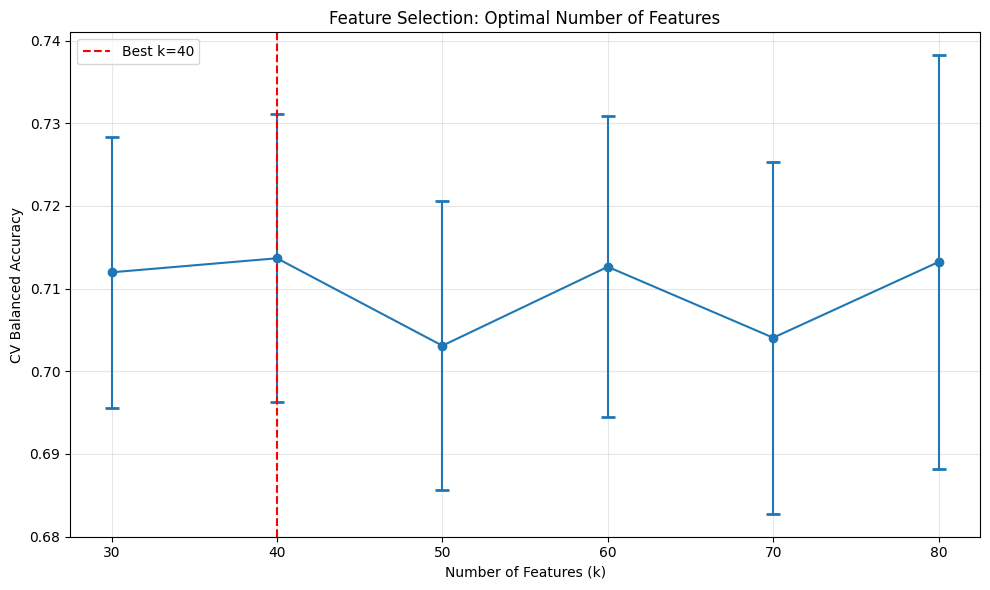

In [27]:
k_values = [30, 40, 50, 60, 70, 80]
results = []

print("Testing different feature selection k values...")
print("=" * 60)

for k in k_values:
    selector_k = SelectKBest(mutual_info_classif, k=k)
    X_train_k = selector_k.fit_transform(X_train_transformed, y_train)
    X_test_k = selector_k.transform(X_test_transformed)
    
    temp_pipeline = Pipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=100,
            learning_rate=0.01,
            max_depth=3,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )),
    ])
    
    cv_strategy_k = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores_k = cross_val_score(temp_pipeline, X_train_k, y_train, cv=cv_strategy_k, scoring='balanced_accuracy')
    
    results.append({
        'k': k,
        'cv_mean': cv_scores_k.mean(),
        'cv_std': cv_scores_k.std()
    })
    
    print(f"k={k:2d}: CV Balanced Accuracy = {cv_scores_k.mean():.4f} (+/- {cv_scores_k.std()*2:.4f})")

results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['cv_mean'].idxmax(), 'k']
best_score = results_df.loc[results_df['cv_mean'].idxmax(), 'cv_mean']

print("\n" + "=" * 60)
print(f"Best k: {best_k} features (CV Balanced Accuracy: {best_score:.4f})")
print("\nRecommendation: Consider using k={} instead of k=50 if performance is better".format(best_k))

plt.figure(figsize=(10, 6))
plt.errorbar(results_df['k'], results_df['cv_mean'], 
             yerr=results_df['cv_std'], 
             marker='o', capsize=5, capthick=2)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Features (k)')
plt.ylabel('CV Balanced Accuracy')
plt.title('Feature Selection: Optimal Number of Features')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [28]:
if categorical_features:
    categorical_data_used = X[categorical_features].copy()
    print(f'Kategorische Features: {len(categorical_features)} -> {categorical_features}')
    print('Form des kategorialen Datensatzes:', categorical_data_used.shape)
    display(categorical_data_used)
else:
    print('Keine kategorialen Features für dieses Modell gefunden.')


Kategorische Features: 7 -> ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Form des kategorialen Datensatzes: (1678, 7)


,ANY_OPE,ANY_OPO,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,Osteoporose_T_Wert_abhängig,currsmo0,diabetes_ADA_final_0,geschlecht
0,0.0,0.0,0.0,0.0,0,1,0
1,0.0,0.0,0.0,0.0,0,0,0
2,1.0,0.0,0.0,0.0,0,1,0
3,0.0,0.0,0.0,0.0,0,1,0
4,1.0,0.0,1.0,0.0,1,1,1
...,...,...,...,...,...,...,...
1673,nan,nan,nan,nan,0,0,1
1674,nan,nan,nan,nan,0,0,0
1675,nan,nan,nan,nan,0,0,0
1676,nan,nan,nan,nan,0,1,0
